In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/data.csv')
df.head()

Mounted at /content/drive


,Дата,Склад,Контрагент,Номенклатура,Количество
0,2018-01-04,1,address_0,product_0,4
1,2018-01-04,1,address_0,product_1,4
2,2018-01-04,1,address_0,product_2,5
3,2018-01-04,1,address_0,product_3,10
4,2018-01-04,1,address_0,product_4,2


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301355 entries, 0 to 301354
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   Дата          301355 non-null  object
 1   Склад         301355 non-null  int64 
 2   Контрагент    301355 non-null  object
 3   Номенклатура  301355 non-null  object
 4   Количество    301355 non-null  int64 
dtypes: int64(2), object(3)
memory usage: 11.5+ MB


In [ ]:
df['Дата'] = pd.to_datetime(df['Дата'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301355 entries, 0 to 301354
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   Дата          301355 non-null  datetime64[ns]
 1   Склад         301355 non-null  int64         
 2   Контрагент    301355 non-null  object        
 3   Номенклатура  301355 non-null  object        
 4   Количество    301355 non-null  int64         
dtypes: datetime64[ns](1), int64(2), object(2)
memory usage: 11.5+ MB


In [ ]:
daily_sales_count = df.groupby('Дата').size().reset_index(name='Количество продаж')
display(daily_sales_count.head())

,Дата,Количество продаж
0,2018-01-04,1840
1,2018-01-05,1301
2,2018-01-06,1306
3,2018-01-07,1322
4,2018-01-09,1719


In [ ]:
display(daily_sales_count.head())

,Дата,Количество продаж
0,2018-01-04,1840
1,2018-01-05,1301
2,2018-01-06,1306
3,2018-01-07,1322
4,2018-01-09,1719


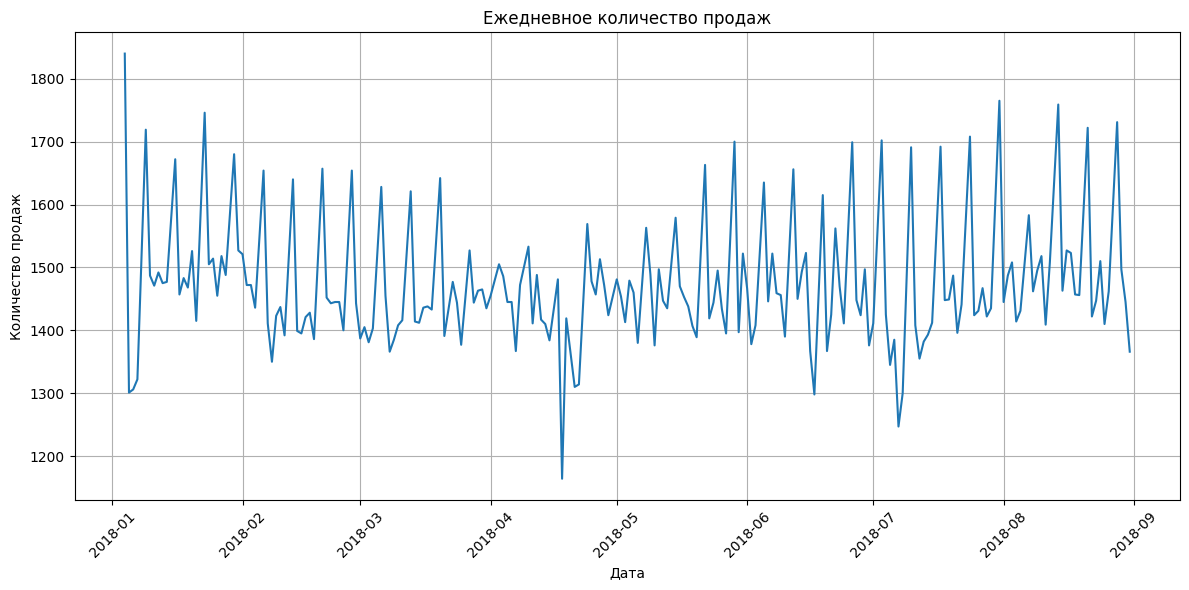

In [ ]:
plt.figure(figsize=(12, 6))
sns.lineplot(x='Дата', y='Количество продаж', data=daily_sales_count)
plt.title('Ежедневное количество продаж')
plt.xlabel('Дата')
plt.ylabel('Количество продаж')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

На графике "Ежедневное количество продаж" отображена динамика продаж по датам с января по конец августа 2018 года. Мы можем наблюдать следующие тенденции:

Общий тренд: В целом, график демонстрирует колеблющуюся, но относительно стабильную картину ежедневных продаж на протяжении всего периода. Нет ярко выраженных долгосрочных трендов к значительному росту или падению.
Ежедневные колебания: Присутствуют заметные ежедневные или еженедельные колебания количества продаж. Это может быть связано с днями недели (например, выходные дни могут иметь другую динамику продаж по сравнению с буднями) или сезонными факторами.
Пики и спады: Можно увидеть отдельные пики продаж, например, в начале января, что может быть связано с новогодними праздниками. Также есть несколько других высоких точек в течение года, которые могут соответствовать особым акциям, праздникам или другим событиям. Аналогично, наблюдаются и спады продаж, например, некоторые дни с очень низким количеством продаж.
Периодичность: Возможно, прослеживается некоторая периодичность в этих колебаниях, что может указывать на еженедельный цикл продаж.
Масштаб: Ось Y показывает количество продаж, которое варьируется примерно от 1000 до более чем 2000 единиц в день.

In [ ]:
Q1 = df['Количество'].quantile(0.25)
Q3 = df['Количество'].quantile(0.75)
IQR = Q3 - Q1

upper_bound = Q3 + 1.5 * IQR
lower_bound = Q1 - 1.5 * IQR

outliers = df[(df['Количество'] < lower_bound) | (df['Количество'] > upper_bound)]

if not outliers.empty:
    max_outlier_row = outliers.loc[outliers['Количество'].idxmax()]
    print(f"Строка с максимальным выбросом по количеству продаж (значение: {max_outlier_row['Количество']}):")
    display(max_outlier_row)
else:
    print("Выбросы по количеству продаж не найдены.")

Строка с максимальным выбросом по количеству продаж (значение: 200):


,218822
Дата,2018-06-28 00:00:00
Склад,1
Контрагент,address_208
Номенклатура,product_0
Количество,200


In [ ]:
display(daily_avg_temp.head())

,Дата,Средняя температура
0,2018-01-04,-13.0875
1,2018-01-05,-17.2500
2,2018-01-06,-14.1250
3,2018-01-07,-12.3375
4,2018-01-08,-15.4375


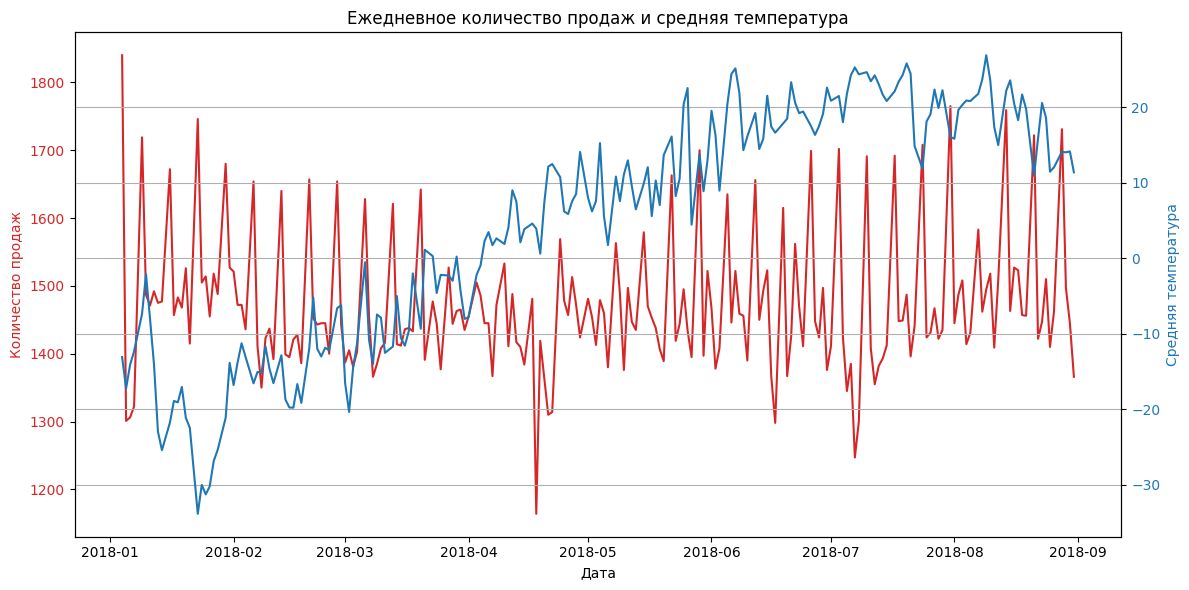

In [ ]:
fig, ax1 = plt.subplots(figsize=(12, 6))

color = 'tab:red'
ax1.set_xlabel('Дата')
ax1.set_ylabel('Количество продаж', color=color)
sns.lineplot(x='Дата', y='Количество продаж', data=merged_df, ax=ax1, color=color)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()
color = 'tab:blue'
ax2.set_ylabel('Средняя температура', color=color)
sns.lineplot(x='Дата', y='Средняя температура', data=merged_df, ax=ax2, color=color)
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Ежедневное количество продаж и средняя температура')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

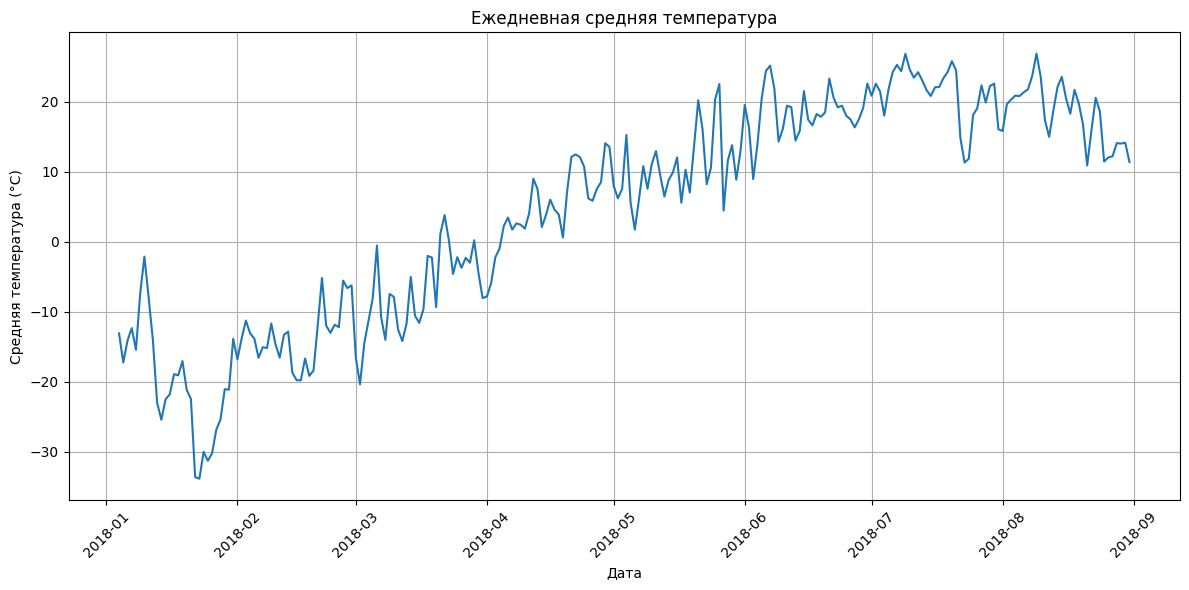

In [ ]:
plt.figure(figsize=(12, 6))
sns.lineplot(x='Дата', y='Средняя температура', data=daily_avg_temp)
plt.title('Ежедневная средняя температура')
plt.xlabel('Дата')
plt.ylabel('Средняя температура (°C)')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()